In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from tensorflow import keras

import warnings
warnings.filterwarnings("ignore")

In [2]:
DataFrameChurn = pd.read_csv("dataset.csv")
DataFrameChurn.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6746,8976-OQHGT,Female,0,Yes,Yes,4,Yes,No,DSL,No,...,No,Yes,No,No,Month-to-month,No,Mailed check,56.50,235.1,Yes
3353,4536-PLEQY,Male,0,Yes,No,12,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Credit card (automatic),85.05,999.8,No
3412,4854-SSLTN,Male,0,Yes,Yes,2,Yes,No,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,59.50,130.5,No
5619,4619-EVPHY,Female,1,Yes,No,20,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,One year,Yes,Bank transfer (automatic),91.00,1859.5,No
1946,7449-HVPIV,Male,0,Yes,Yes,55,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),90.40,5099.15,No


In [3]:
DataFrameChurn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
DataFrameChurn.dropna(inplace=True)
DataFrameChurn.drop("customerID", axis="columns", inplace=True)

# Exploratory Data Analysis

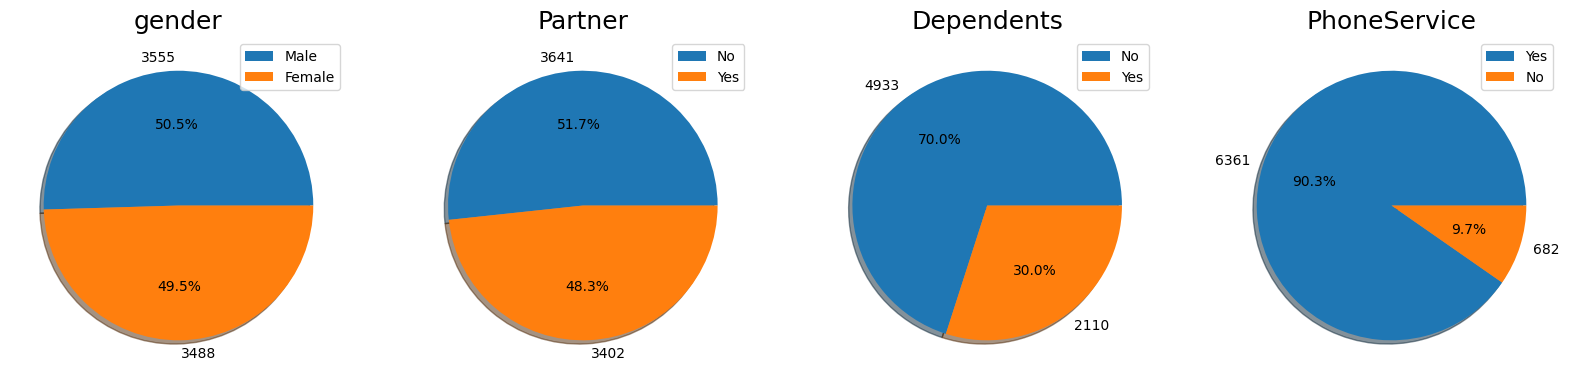

In [5]:
categoryColumns = list(DataFrameChurn.select_dtypes(include=['object']).columns)

_, axesPlot = plt.subplots(1, 4, figsize=(20, 12))

for index, feature in enumerate(categoryColumns[:4]):
    pieAxis = axesPlot[index]
    countData = DataFrameChurn[feature].value_counts()
    pieAxis.pie(countData,
                labels=countData.values,
                autopct="%1.1f%%",
                shadow=True)
    pieAxis.set_title(feature, size=18)
    pieAxis.legend(countData.index)

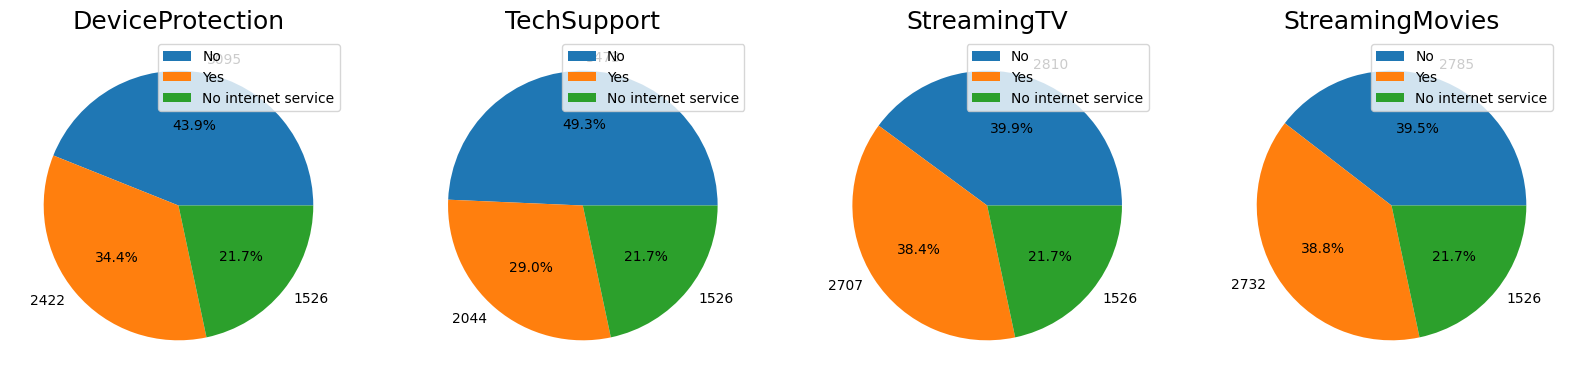

In [6]:
_, axesPlot = plt.subplots(1, 4, figsize=(20, 12))

for index, feature in enumerate(categoryColumns[8:12]):
    pieAxis = axesPlot[index]
    countData = DataFrameChurn[feature].value_counts()
    pieAxis.pie(countData,
                labels=countData.values,
                autopct="%1.1f%%")
    pieAxis.set_title(feature, size=18)
    pieAxis.legend(countData.index)

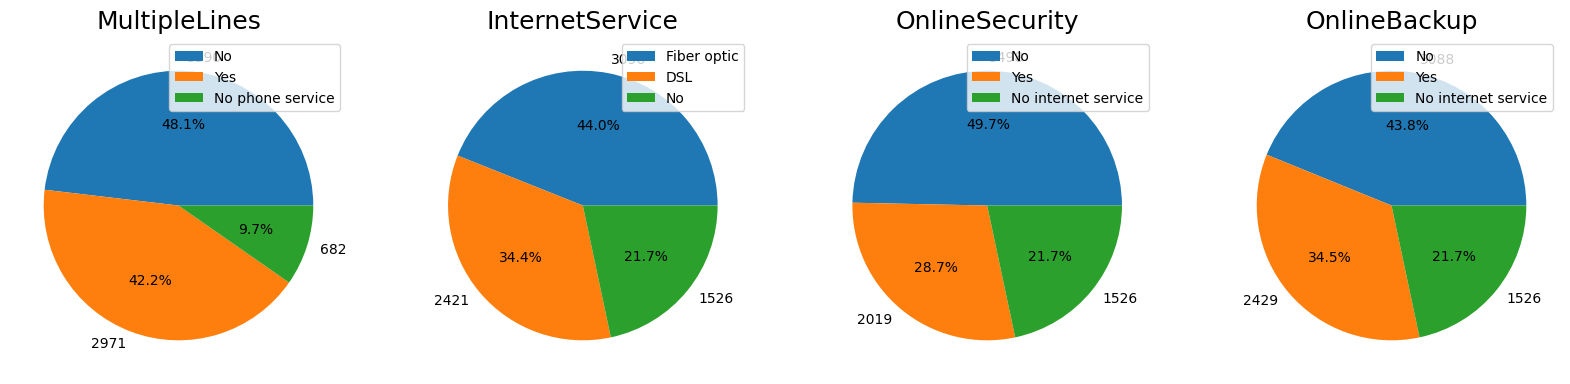

In [7]:
_, axesPlot = plt.subplots(1, 4, figsize=(20, 12))

for index, feature in enumerate(categoryColumns[4:8]):
    pieAxis = axesPlot[index]
    countData = DataFrameChurn[feature].value_counts()
    pieAxis.pie(countData,
                labels=countData.values,
                autopct="%1.1f%%")
    pieAxis.set_title(feature, size=18)
    pieAxis.legend(countData.index, loc="best")

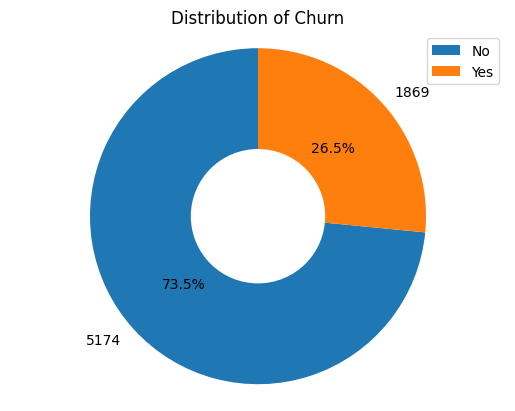

In [8]:
figure, singleAxis = plt.subplots()
churnDistribution = DataFrameChurn["Churn"].value_counts()

singleAxis.pie(churnDistribution,
               autopct='%1.1f%%',
               startangle=90,
               labels=churnDistribution.values)

singleAxis.legend(churnDistribution.index)
singleAxis.set_title("Distribution of Churn")
centerCircle = plt.Circle((0, 0), 0.4, fc='white')
imgaes = plt.gcf()
imgaes.gca().add_artist(centerCircle)
singleAxis.axis('equal');

[Text(0.5, 0, 'Count')]

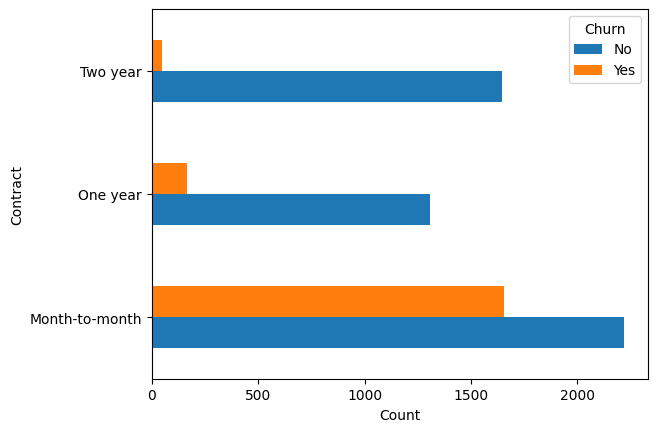

In [9]:
_, singleAxis = plt.subplots()
pd.crosstab(DataFrameChurn["Contract"], DataFrameChurn["Churn"]).plot(kind="barh", ax=singleAxis)
singleAxis.set(xlabel="Count")

<Axes: xlabel='Churn', ylabel='tenure'>

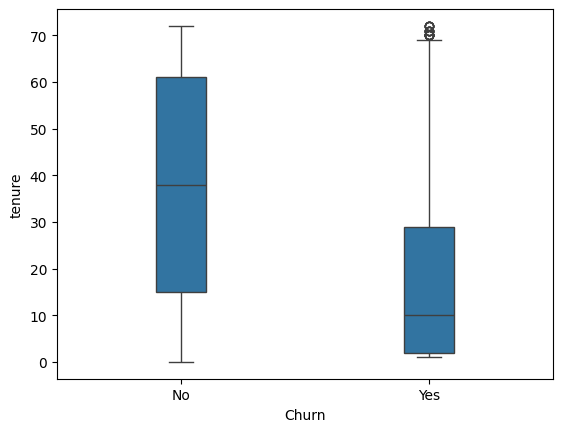

In [10]:
sns.boxplot(data=DataFrameChurn, x="Churn", y="tenure", width=0.2)

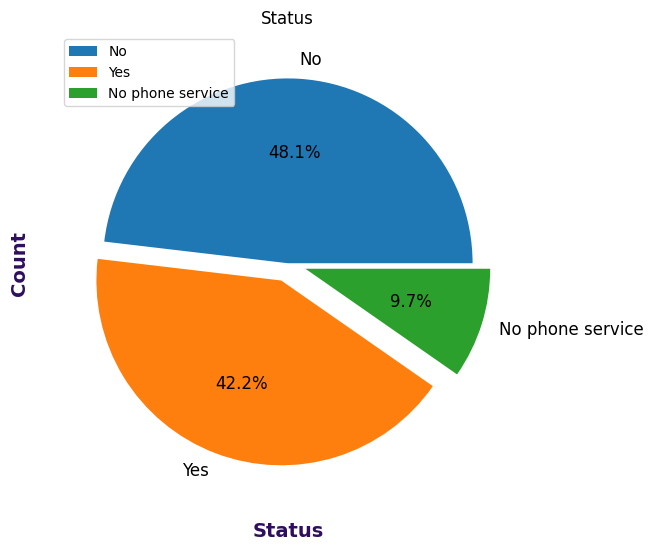

In [11]:
plt.figure(figsize=(20, 6))

lineCounts = DataFrameChurn["MultipleLines"].value_counts()
explodeSetting = (0, 0.1, 0.1)

lineCounts.plot(kind='pie', fontsize=12, explode=explodeSetting, autopct='%.1f%%')

plt.title('Status')

plt.xlabel('Status',
           weight="bold",
           color="#2F0F5D",
           fontsize=14,
           labelpad=20)

plt.ylabel('Count',
           weight="bold",
           color="#2F0F5D",
           fontsize=14,
           labelpad=20)
plt.legend(labels=lineCounts.index, loc="best")
plt.show()

# Cleaning data

### One hot encoding non numerical columns

In [12]:
mappingDict = {'No phone service': 0, 'No': 0, 'Yes': 1}

DataFrameChurn['MultipleLines'] = DataFrameChurn['MultipleLines'].map(mappingDict)

DataFrameChurn['gender'] = DataFrameChurn['gender'].map({'Male': 0, 'Female': 1})

DataFrameChurn['Partner'] = DataFrameChurn['Partner'].map({'No': 0, 'Yes': 1})

DataFrameChurn['Dependents'] = DataFrameChurn['Dependents'].map({'No': 0, 'Yes': 1})

DataFrameChurn['PhoneService'] = DataFrameChurn['PhoneService'].map({'No': 0, 'Yes': 1})

In [13]:
DataFrameChurn.replace('No internet service', 'No', inplace=True)

DataFrameChurn.replace('No phone service', 'No', inplace=True)

yesNoColumns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for column in yesNoColumns:
    DataFrameChurn[column].replace({'Yes': 1, 'No': 0}, inplace=True)

DataFrameChurn = DataFrameChurn[DataFrameChurn.TotalCharges != ' ']

colsToScale = ['tenure', 'MonthlyCharges', 'TotalCharges']

minMaxScaler = MinMaxScaler()
DataFrameChurn[colsToScale] = minMaxScaler.fit_transform(DataFrameChurn[colsToScale])

In [14]:
labelEncoder = LabelEncoder()
DataFrameChurn.InternetService = labelEncoder.fit_transform(DataFrameChurn.InternetService)
DataFrameChurn.Contract = labelEncoder.fit_transform(DataFrameChurn.Contract)
DataFrameChurn.PaymentMethod = labelEncoder.fit_transform(DataFrameChurn.PaymentMethod)

In [15]:
DataFrameChurn.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,0.000000,0,0,0,0,1,0,0,0,0,0,1,2,0.115423,0.001275,0
1,0,0,0,0,0.464789,1,0,0,1,0,1,0,0,0,1,0,3,0.385075,0.215867,0
2,0,0,0,0,0.014085,1,0,0,1,1,0,0,0,0,0,1,3,0.354229,0.010310,1
3,0,0,0,0,0.619718,0,0,0,1,0,1,1,0,0,1,0,0,0.239303,0.210241,0
4,1,0,0,0,0.014085,1,0,1,0,0,0,0,0,0,0,1,2,0.521891,0.015330,1


In [16]:
features = DataFrameChurn.drop('Churn', axis='columns')
labels = DataFrameChurn['Churn']

In [17]:
featuresTrain, featuresTest, labelsTrain, labelsTest = train_test_split(features, labels, test_size=0.2, random_state=5)

# Logistic Regression

In [18]:
featuresTrain.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5664,1,1,0,0,0.126761,1,0,1,0,0,1,0,0,1,0,1,1,0.660199,0.097709
101,1,0,1,1,0.000000,1,0,2,0,0,0,0,0,0,0,0,2,0.011940,0.000075
2621,0,0,1,0,0.985915,1,0,0,0,1,1,1,1,1,2,1,1,0.605473,0.639978
392,1,1,0,0,0.014085,1,0,0,0,0,0,0,0,0,0,1,2,0.259204,0.008135
1327,0,0,1,0,0.816901,1,1,1,0,0,1,0,1,1,1,1,0,0.808458,0.685703


In [19]:
model = LogisticRegression()

paramsGrid = {
    'C': [0.1, 1],
    'penalty': ['l1', 'l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [100],
    'l1_ratio': [0, 0.5, 1]
}

searchGrid = GridSearchCV(estimator=model, param_grid=paramsGrid, cv=5, scoring='accuracy', verbose=1)
searchGrid.fit(featuresTrain, labelsTrain)

print("Best parameters: ", searchGrid.best_params_)
print("Best cross-validation score: {:.2f}".format(searchGrid.best_score_))

predictedLabels = searchGrid.predict(featuresTest)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:  {'C': 1, 'l1_ratio': 0, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation score: 0.81


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       999
           1       0.67      0.57      0.62       408

    accuracy                           0.79      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.79      0.79      0.79      1407



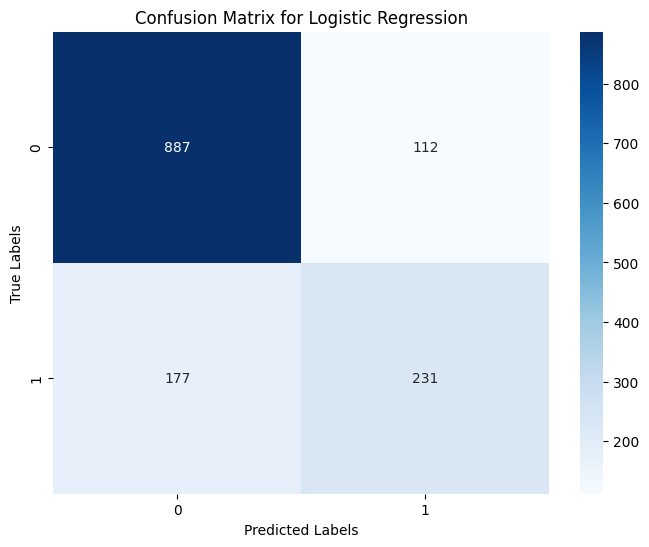

In [20]:
print("Classification Report:")
print(classification_report(labelsTest, predictedLabels))

# Confusion Matrix
confMatrix = confusion_matrix(labelsTest, predictedLabels)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confMatrix, annot=True, fmt="d", cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Neural Networks

In [21]:
neuralModel = keras.Sequential([
    keras.layers.Dense(15, input_shape=(19,), activation='relu'),
    keras.layers.Dense(15, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [22]:
neuralModel.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

neuralModel.fit(featuresTrain, labelsTrain, epochs=20)

Epoch 1/20
176/176 [==============================] - 3s 5ms/step - loss: 0.5167 - accuracy: 0.7461
Epoch 2/20
176/176 [==============================] - 1s 5ms/step - loss: 0.4469 - accuracy: 0.7833
Epoch 3/20
176/176 [==============================] - 2s 9ms/step - loss: 0.4329 - accuracy: 0.7908
Epoch 4/20
176/176 [==============================] - 1s 6ms/step - loss: 0.4263 - accuracy: 0.7947
Epoch 5/20
176/176 [==============================] - 1s 3ms/step - loss: 0.4225 - accuracy: 0.7941
Epoch 6/20
176/176 [==============================] - 0s 3ms/step - loss: 0.4202 - accuracy: 0.7996
Epoch 7/20
176/176 [==============================] - 0s 3ms/step - loss: 0.4182 - accuracy: 0.7998
Epoch 8/20
176/176 [==============================] - 0s 3ms/step - loss: 0.4181 - accuracy: 0.8028
Epoch 9/20
176/176 [==============================] - 0s 3ms/step - loss: 0.4154 - accuracy: 0.8039
Epoch 10/20
176/176 [==============================] - 0s 2ms/step - loss: 0.4138 - accuracy: 0.8053

In [23]:
neuralModel.evaluate(featuresTest, labelsTest)

44/44 [==============================] - 0s 2ms/step - loss: 0.4438 - accuracy: 0.7804


[0.44377776980400085, 0.7803837656974792]

In [24]:
nnPredictions = neuralModel.predict(featuresTest)

nnPredictedLabels = []
for prediction in nnPredictions:
    if prediction > 0.5:
        nnPredictedLabels.append(1)
    else:
        nnPredictedLabels.append(0)

44/44 [==============================] - 0s 2ms/step


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       999
           1       0.66      0.50      0.57       408

    accuracy                           0.78      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.77      0.78      0.77      1407



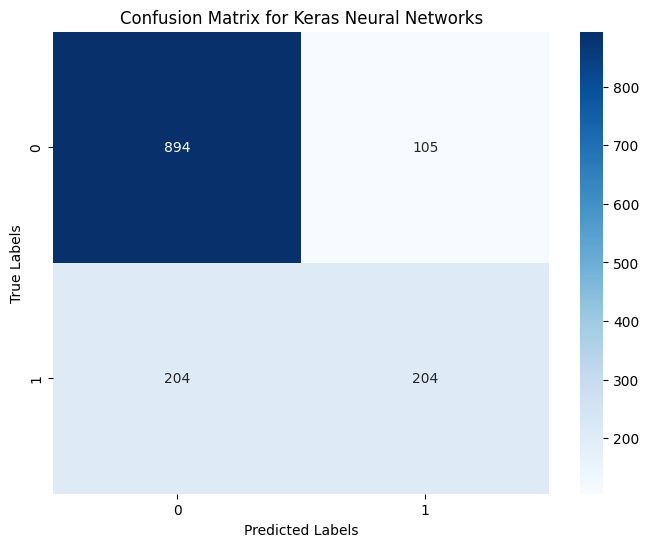

In [25]:
print("Classification Report:")
print(classification_report(labelsTest, nnPredictedLabels))

# Confusion Matrix
confusionMatrixNN = tf.math.confusion_matrix(labels=labelsTest, predictions=nnPredictedLabels)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusionMatrixNN, annot=True, fmt="d", cmap='Blues')
plt.title('Confusion Matrix for Keras Neural Networks')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()